# 6-2 用 Puell Multiple 找到價格低點

[![在 Colab 開啟](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/finlab-python/hahow-crypto-course/blob/main/6-2_puell_multiple.ipynb)

**對應影片**：第 6 章 單元 6-2【基本面策略】用 Puell Multiple 找到價格低點

**和影片的差異**

- 影片用的 cryptocmd 套件已失效，後來改用的 yfinance 只有 2014 年以後的 BTC 價格；這裡改用 Coin Metrics 社群版的 `PriceUSD`（2010 年起，免金鑰）。
- 減半日期更新到 2024-04-20（區塊獎勵 3.125 BTC），並補上 2009 年起的 50 BTC。
- 每天約產生 144 個區塊（影片寫 900）；這個常數在分子分母會約掉，不影響 Puell Multiple 的數值。
- 平均改用 365 天（影片為 360 天），和指標原始定義一致。
- 最後多一段：和 Coin Metrics 實際發行量算出的 Puell Multiple 比對。

In [1]:
%pip install -q finlab_crypto==0.3.0

Note: you may need to restart the kernel to use updated packages.


# 下載比特幣歷史價格

資料來源：[Coin Metrics Community Data](https://coinmetrics.io/community-network-data/)（CC BY-NC 4.0，公開分享結果時請註明）。

<Axes: xlabel='timestamp'>

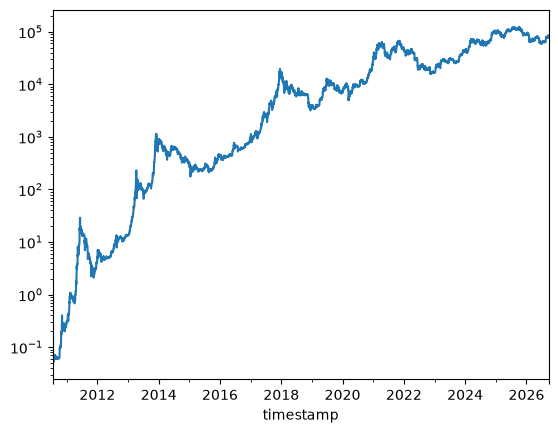

In [2]:
import pandas as pd
from finlab_crypto import onchain

btc = onchain.coinmetrics(['PriceUSD', 'IssTotUSD'])
close = btc.PriceUSD.dropna()
close.plot(logy=True)

# The Puell Multiple

[The Puell Multiple](https://medium.com/unconfiscatable/the-puell-multiple-bed755cfe358)：
礦工每天挖到的比特幣價值 ÷ 過去 365 天的平均。數值很低代表礦工收入少、價格相對便宜。

- [reindex](https://pandas.pydata.org/docs/reference/api/pandas.Series.reindex.html)：把減半表對齊到每一天
- [rolling](https://pandas.pydata.org/docs/reference/api/pandas.Series.rolling.html)：除以 365 天平均，讓不同年代的數值可以比較（normalize）

<Axes: xlabel='timestamp'>

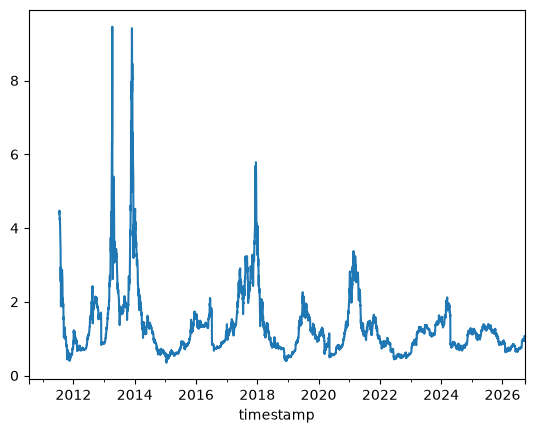

In [3]:
HALVINGS = {
    '2009-01-03': 50,
    '2012-11-28': 25,
    '2016-07-09': 12.5,
    '2020-05-11': 6.25,
    '2024-04-20': 3.125,
}
BLOCKS_PER_DAY = 144
PUELL_WINDOW = 365

reward = pd.Series(HALVINGS)
reward.index = pd.to_datetime(reward.index, utc=True)
reward = reward.reindex(close.index, method='ffill')

daily_value_mined = reward * close * BLOCKS_PER_DAY
puell_multiple = daily_value_mined / daily_value_mined.rolling(PUELL_WINDOW).mean()
puell_multiple.plot()

## 每月底的指標與漲跌幅

`resample('ME')` 以月底為單位，`.last()` 取每月最後一天。

In [4]:
mindicator = puell_multiple.resample('ME').last().dropna()
mclose = close.resample('ME').last().reindex(mindicator.index)
mpct_change = mclose.pct_change().fillna(0) + 1

## 模擬資金進出

- 便宜（Puell Multiple < 3）：每月投入 10,000
- 昂貴：每月賣出 20% 的部位

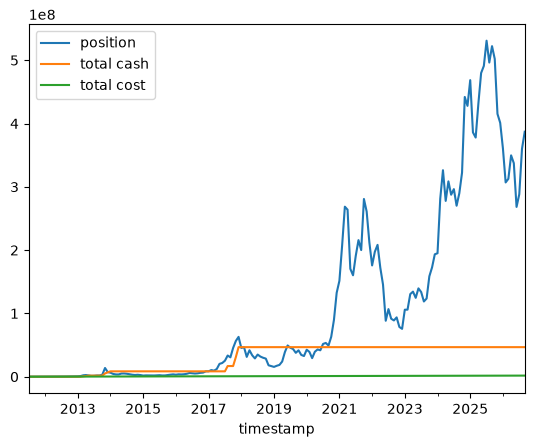

In [5]:
CHEAP_THRESHOLD = 3
MONTHLY_BUDGET = 10000
SELL_RATIO = 0.2

position = [0]  # 持有部位的價值，一開始沒有持有
cash = [0]      # 每月賣出拿回的現金
cost = [0]      # 每月投入的成本

for pct_change, ind in zip(mpct_change, mindicator):
    # 上個月的部位隨價格漲跌
    newposition = position[-1] * pct_change

    if ind < CHEAP_THRESHOLD:
        delta = MONTHLY_BUDGET
    else:
        delta = -SELL_RATIO * newposition

    position.append(newposition + delta)
    cash.append(-delta if delta < 0 else 0)
    cost.append(delta if delta > 0 else 0)

position = pd.Series(position[1:], index=mclose.index)
cash = pd.Series(cash[1:], index=mclose.index)
cost = pd.Series(cost[1:], index=mclose.index)

import matplotlib.pyplot as plt

position.plot(label='position')
cash.cumsum().plot(label='total cash')
cost.cumsum().plot(label='total cost')
plt.legend()

## 補充：用實際發行量計算

Coin Metrics 的 `IssTotUSD` 是每天新發行比特幣的美元價值，直接拿來算就是「官方定義」的 Puell Multiple。
和上面用減半表推算的結果幾乎重疊。

<Axes: xlabel='timestamp'>

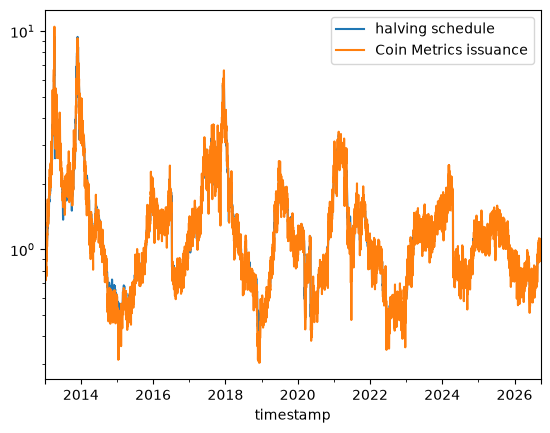

In [6]:
issuance = btc.IssTotUSD.dropna()
official = issuance / issuance.rolling(PUELL_WINDOW).mean()

pd.DataFrame({'halving schedule': puell_multiple, 'Coin Metrics issuance': official}).loc['2013':].plot(logy=True)